# SpecklePattern

### Run on kernel "Python [conda env:base]"

In [1]:
import numpy as np
import matplotlib.pyplot as py

In [2]:
# Gaussian Point (Needs optimisation)
def GaussPoint(position,variance):
    # Gaussian Point
    # Inputs:
    # position - Input an array containing the x and y position of the object respectively
    # variance - Determines the width of the gaussian point
    #
    # Outputs:
    # gaussian - matrix containing the gaussian point
    
    maxgauss = 0

    gaussian = np.empty((dimensions,dimensions)) # Create an empty matrix the size of the speckle pattern

    for i in range(dimensions**2): # Repeat the following for each item in the speckle pattern
        ycoord = int(np.trunc(i/dimensions)) # Find the x and y coordinates of the current item
        xcoord = int(i - ycoord*dimensions)

        # Produce a gaussian around the specified point as the product of gaussian curves in the x and y directions
        gaussian[xcoord,ycoord] = ((1/(2*np.pi*variance**2))*np.exp(-((xcoord-position[1])**2)/(2*variance**2)) 
                            * (1/(2*np.pi*variance**2))*np.exp(-((ycoord-position[0])**2)/(2*variance**2)))/2
        
        if gaussian[xcoord,ycoord] > maxgauss: # Ensure the gaussians maximum value is 1
            maxgauss = gaussian[xcoord,ycoord]

    gaussian = gaussian/maxgauss
    return gaussian 

In [3]:
# Form random complex speckle pattern

dimensions = 512 # dimensions refers to the length of one side of the speckle pattern (speckle pattern is a square)
padding = 400
halfpadding = int(np.round(padding/2))

Rspeckle = np.random.randint(low=-1, high=2, size=(dimensions-padding,dimensions-padding)) # Produce a speckle pattern made of random real
Ispeckle = np.random.randint(low=-1, high=2, size=(dimensions-padding,dimensions-padding)) # and imaginary values from 0 to 1 and combine
speckle = Ispeckle.astype(np.complex64)                      # to make a complex speckle pattern

for i in range((dimensions-padding)**2):
    ycoord = int(np.trunc(i/(dimensions-padding)))
    xcoord = int(i - ycoord*(dimensions-padding))
    speckle[xcoord,ycoord] = np.complex64(Rspeckle[xcoord,ycoord], Ispeckle[xcoord,ycoord])

In [4]:
speckle = np.pad(speckle, (halfpadding, halfpadding))

In [5]:
Fspeckle = np.fft.fft2(speckle) # Perform a Fourier transform on the speckle pattern

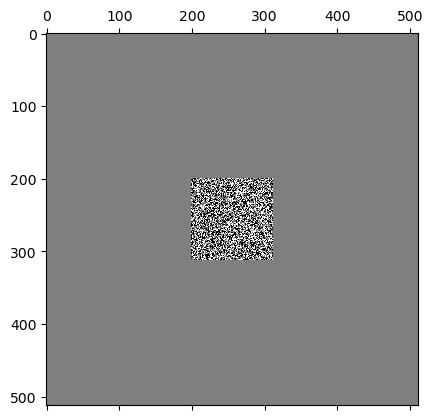

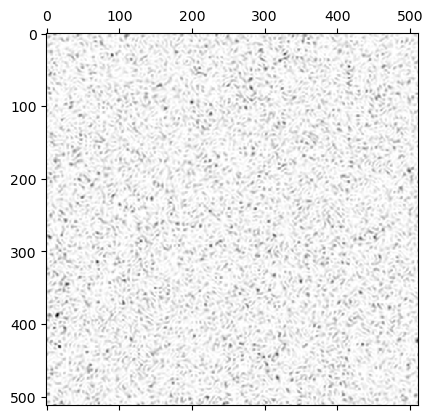

In [6]:
py.matshow((np.real(speckle)), fignum=None, cmap="binary") # Plot the speckle pattern
py.savefig("Speckle_raw(print).pdf", format="pdf")
py.matshow((np.abs(Fspeckle)**2), fignum=None, cmap="binary") # Plot the Fourier transform
py.savefig("Speckle(print).pdf", format="pdf")

In [7]:
mean = Fspeckle.mean() # Find the mean value of the new speckle pattern
#py.savefig("Speckle_final.pdf", format="pdf")

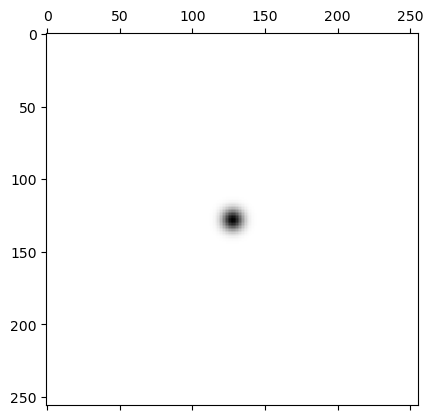

In [43]:
# Object: 1 dot

objects = 0
objects = GaussPoint((128,128),5) # Add gaussian point as objects to image
py.matshow(objects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_1dot.pdf", format="pdf")

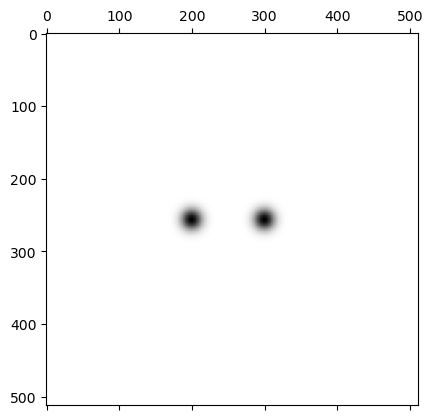

In [8]:
# Object: 2 dots

objects = 0
objects = GaussPoint((200,256),10) + GaussPoint((300,256),10) # Add gaussian point as objects to image
py.matshow(objects, fignum=None, cmap="binary") # Plot objects
py.savefig("Object_2dot(print).pdf", format="pdf")

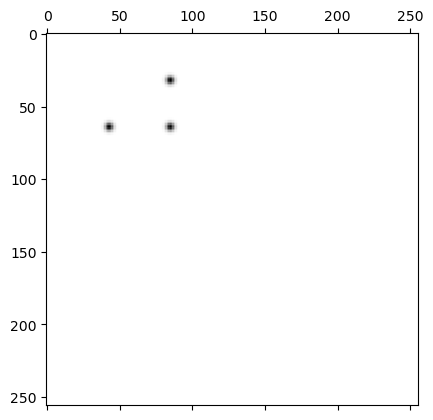

In [46]:
# Object: 3 dots

objects = 0
objects = GaussPoint((43,64),2) + GaussPoint((85,64),2) + GaussPoint((85,32),2) # Add gaussian point as objects to image
py.matshow(objects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_3dot.pdf", format="pdf")

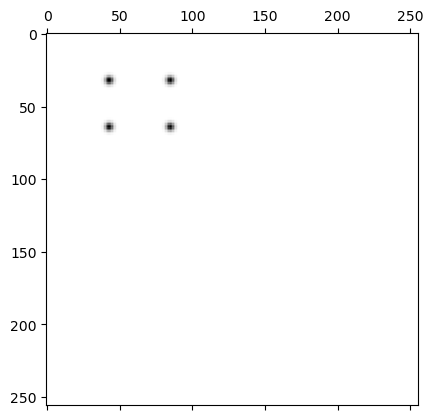

In [47]:
# Object: 4 dots

objects = 0
objects = GaussPoint((43,64),2) + GaussPoint((85,64),2) + GaussPoint((85,32),2) + GaussPoint((43,32),2) # Add gaussian point as objects to image
py.matshow(objects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_4dot.pdf", format="pdf")

In [23]:
# Object: Line (slower)

objects = 0
for i in range (0,80,1):
    objects += GaussPoint((60, 20+i), 1) # Add gaussian point as objects to image
py.matshow(objects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_1line.pdf", format="pdf")

KeyboardInterrupt: 

In [ ]:
# Object: 2 lines (slower)

objects = 0
for i in range (80):
    objects += GaussPoint((40, 20+i), 1) + GaussPoint((80, 20+i), 1) # Add gaussian point as objects to image
py.matshow(objects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_2line.pdf", format="pdf")

In [ ]:
# Object: Square (slower)

objects = 0
for i in range (40):
    objects += GaussPoint((40, 40+i), 1) + GaussPoint((80, 40+i), 1) + GaussPoint((40+i, 40), 1) + GaussPoint((40+i, 80), 1) # Add gaussian point as objects to image
py.matshow(objects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_square.pdf", format="pdf")

In [ ]:
# Object: Letter F (slower)

objects = 0
for i in range (80):
    objects += GaussPoint((40, 20+i), 1)  # Add gaussian point as objects to image
    if i < 40:
        objects += GaussPoint((40+i,20),1) + GaussPoint((40+i,60),1)
py.matshow(objects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_letterF.pdf", format="pdf")

In [ ]:
# Object: Letter I (slower)

objects = 0
for i in range (80):
    objects += GaussPoint((64, 20+i), 1)  # Add gaussian point as objects to image
    if i < 40:
        objects += GaussPoint((44+i,20),1) + GaussPoint((44+i,100),1)
py.matshow(objects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_letterI.pdf", format="pdf")

In [ ]:
# Object: Letter N (slower)

objects = 0
for i in range (80):
    objects += GaussPoint((20+i, 20+i), 1)  # Add gaussian point as objects to image
    if i < 80:
        objects += GaussPoint((20, 20+i), 1) + GaussPoint((100, 20+i), 1)
py.matshow(objects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_letterN.pdf", format="pdf")

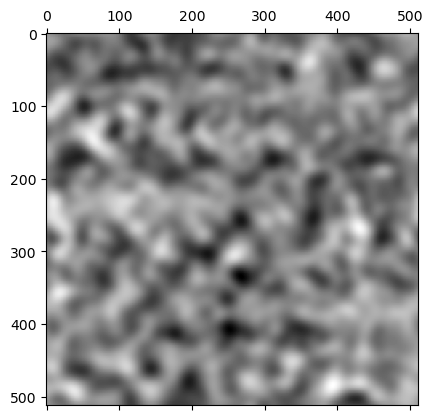

In [9]:
#Convolution

convolution = np.fft.ifft2(np.fft.fft2(objects)*np.fft.fft2(Fspeckle)) # Find the convolution as the inverse
                                                                            # Fourier transform of the product of
                                                                            # Fourier transforms of the object and 
                                                                            # new speckle pattern

py.matshow(np.real(convolution), fignum=None, cmap="binary") # Plot convolution
py.savefig("Convolution_twodot(print).pdf", format="pdf")

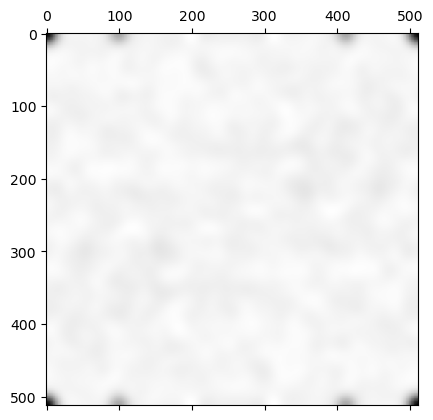

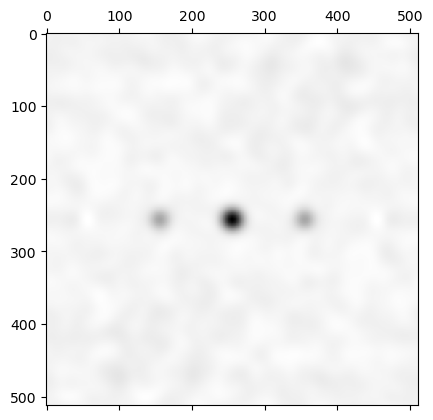

In [10]:
# Autocorrelation

autocorrelation = np.fft.ifft2(np.abs(np.fft.fft2(convolution-mean))) # Find the autocorrelation as the inverse
                                                                      # Fourier transform of the absolute value 
                                                                      # of the Fourier transform of the convolution
                                                                      # minus the mean value of the new speckle
                                                                      # pattern

autocorrelationshift = autocorrelation.copy()

# This produces the autocorrelation but with the focal point at the corners, therefore we want to shift the plot
# to have it in the centre

for i in range(dimensions**2): # Repeat the following for every item in the speckle pattern
    ycoord = int(np.trunc(i/dimensions))
    xcoord = int(i - ycoord*dimensions)

    newycoord = 0
    newxcoord = 0
    
    newycoord = ycoord - dimensions/2 # Shift the current positions of items across by half the width of the matrix
    newxcoord = xcoord - dimensions/2 # in both the x and y direction

    # If the new position would be beyond the width of the matrix, then bring them back to the opposite side
    if newycoord >= dimensions: 
        newycoord = newycoord + dimensions
    if newxcoord >= dimensions:
        newxcoord = newxcoord + dimensions
        
        
    autocorrelationshift[int(newxcoord),int(newycoord)] = autocorrelation[xcoord,ycoord] # Copy over the item to the
                                                                                         # shifted position

py.matshow(np.real(autocorrelation), fignum=None, cmap="binary") # Plot the unshifted autocorrelation
py.matshow(np.real(autocorrelationshift), fignum=None, cmap="binary") # Plot the shifted correlation
py.savefig("Autocorrelation_twodot(Print).pdf", format="pdf")